# I will now be building the basic arithmetic operations from the Clifford + T gate set for 2s complement bit representations

Allowed gates are Clifford gates: H, S, X, Y, Z, I, CNOT and all of their inverses  (add to this list any other Clifford gate I need, this isn't meant to be exhaustive)

and the only non-Clifford gate allowed is T

In [1]:
from math import pi, acos, sqrt
from qiskit import QuantumCircuit, QuantumRegister, Aer, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.circuit.library import StatePreparation, CXGate, XGate, QFT, HGate, RYGate, U1Gate, IntegerComparator, DraperQFTAdder, UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Operator
import numpy as np

import Elementary_circuits.subarithmetic_circuits as subarithmetic_circuits
import Elementary_circuits.basic_arithmetic_circuits as basic_arithmetic_circuits

# Modular Addition for Twos Complement form of integers

In [2]:
# given a non-negative integer val defined using n bits, return the integer represented by the same bit string if it was in twos-complement form
def getTwosComplementInteger(val, n):
    max_contrib = int(2**(n-1)) # magnitide of the largest bit contribution (for both formats)
    if val >= max_contrib:
        return val - 2 * max_contrib
    return val


{'barrier': 9, 'cx': 7, 'ccx': 2, 'unitary': 2}


C:\Users\linco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


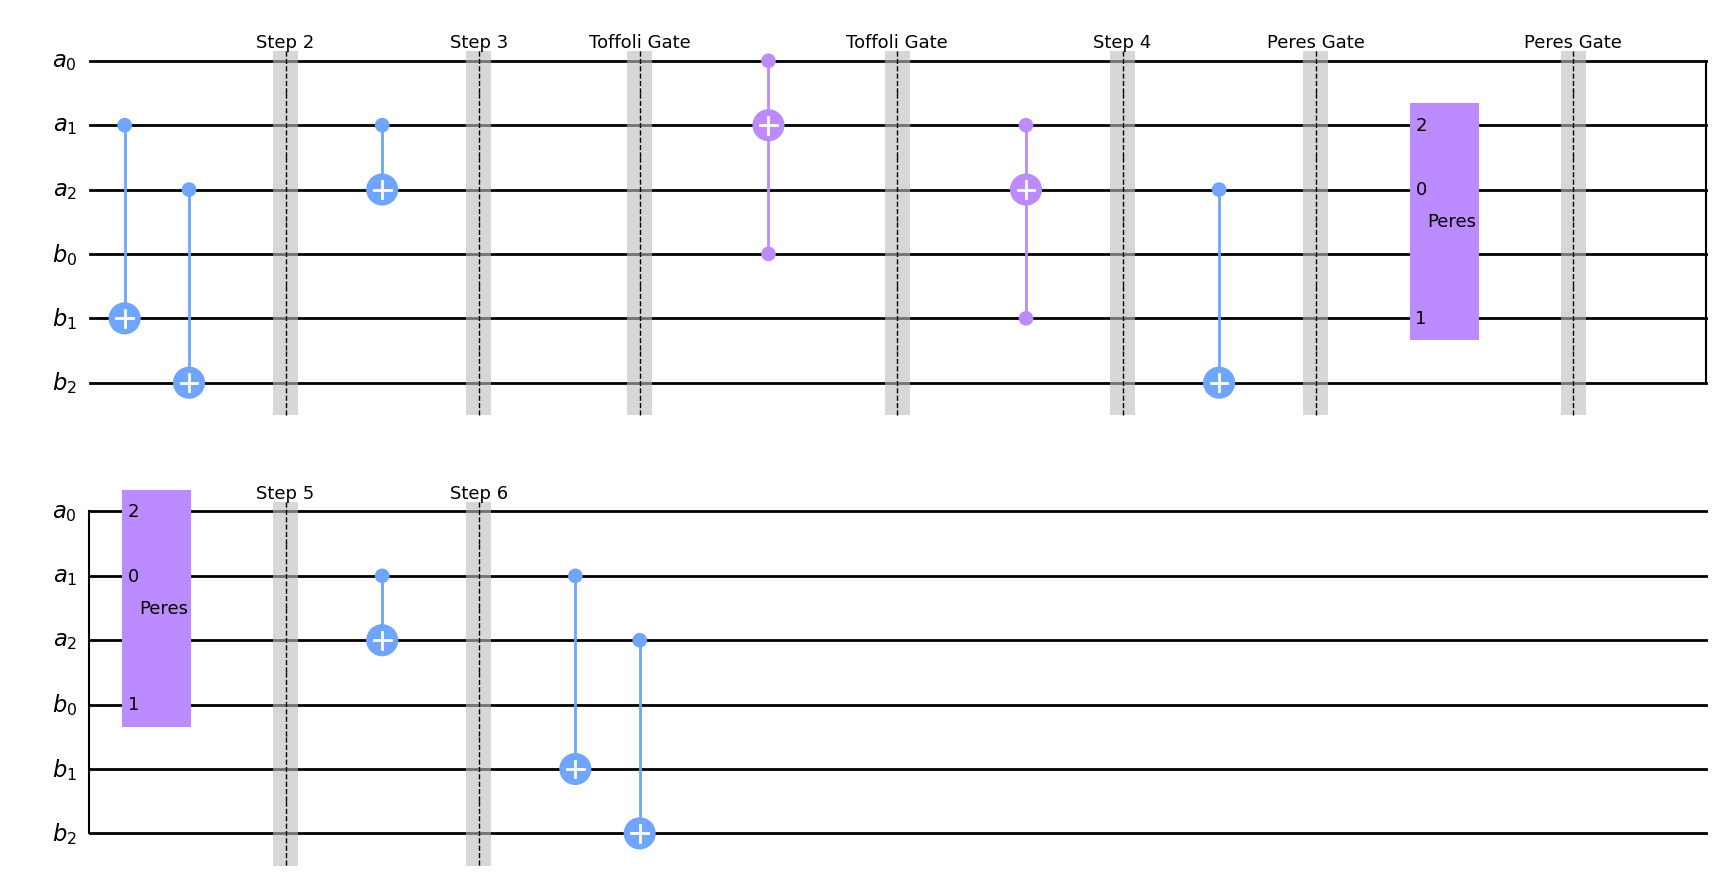

In [3]:
n = 3 # some arbitrary value, integers will be in the range [-2^(n-1), 2^(n-1)-1]
a = QuantumRegister(n, 'a') # "A" register
b = QuantumRegister(n, 'b') # "B" register

qc = QuantumCircuit(a, b)

basic_arithmetic_circuits.Addition_gate(qc, a, b, modular=True, useElementaryGates=False)

# get the unitary of the circuit
U = Operator(qc).data
#print("unitary operator: ", np.round(U, decimals=2))

# run inputs and print outputs
#for b_val in range(int(-2**(n-1) + 1), int(2**(n-1) - 1)):
#    for a_val in range(int(-2**(n-1) + 1), int(2**(n-1) - 1)):
for b_val_std in range(int(2**n)):
    for a_val_std in range(int(2**n)):
        a_val = getTwosComplementInteger(a_val_std, n) # get the a_val for the same bit string in twos complement form
        b_val = getTwosComplementInteger(b_val_std, n)

        integer_input = b_val_std * int(2**n) + a_val_std
        state_vec = np.zeros(int(2**(2*n)))
        state_vec[integer_input] = 1
        input_state = Statevector(state_vec)

        # Apply the circuit to the state
        output_state = input_state.evolve(qc)
        integer_output = np.argmax(output_state.data)
        output_a = getTwosComplementInteger(integer_output % int(2**n), n)
        output_b = getTwosComplementInteger(integer_output // int(2**n), n)

        # Print as numpy array
        #print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
        #print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)

        if output_a != a_val:
            print("output a is not correct")
            print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
            print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)
            #raise Exception("output a is not correct")

        if output_b != (a_val + b_val + int(2**(n-1))) % int(2**n) - int(2**(n-1)): # modular but within the range [-2^(n-1), 2^(n-1) - 1]
            print("output b is not correct")
            print("input: ", state_vec, "   a = ", a_val, "   b = ", b_val)
            print("output: ", np.round(np.real(output_state.data), decimals=2), "   a = ", output_a, "   b = ", output_b)
            #raise Exception("output b is not correct")

print(dict(qc.count_ops()))
qc.draw('mpl')

# 2s Complement
Negating an $n$-qubit two's-complement value means flipping every bit and adding one modulo $2^n$:

$$\ket{a}\ket{0}^{\otimes n} \longrightarrow \ket{(-a)\bmod 2^n}\ket{0}^{\otimes n}.$$

The work register is initialized to zero, temporarily holds the constant one used by the adder, and is returned to zero. Because the operation is a permutation of computational-basis states, it also acts coherently on superpositions.

With $n$ qubits, the most-significant bit has weight $-2^{n-1}$, so the representable signed range is $[-2^{n-1}, 2^{n-1}-1]$.

All 8 basis states and the superposition test passed.
{'barrier': 9, 'cx': 7, 'x': 5, 'ccx': 2, 'unitary': 2}


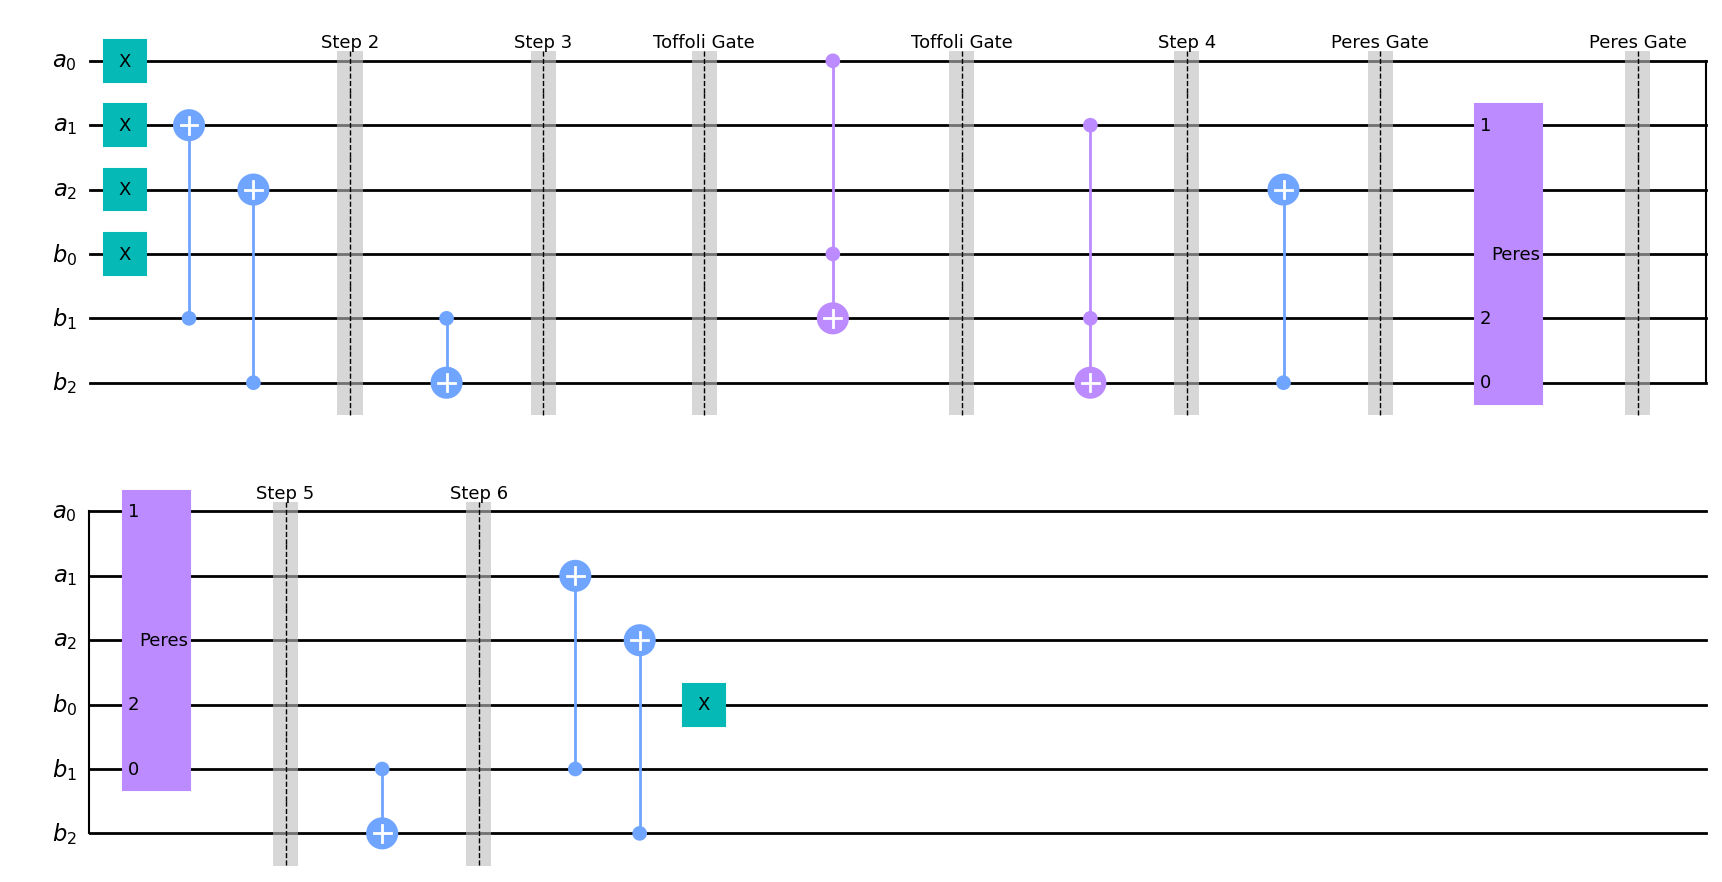

In [4]:
n = 3 # some arbitrary value
a = QuantumRegister(n, 'a') # "A" register
b = QuantumRegister(n, 'b') # "B" register

qc = QuantumCircuit(a, b)

basic_arithmetic_circuits.Twos_complement(qc, a, b)

dimension = 2**n

# Exhaustively test every computational-basis input. The a register should
# contain -a modulo 2^n and the work register should return to zero.
for a_val in range(int(2**n)):
    input_state = Statevector.from_int(a_val, dims=2**(2*n))
    output_state = input_state.evolve(qc)
    expected_a = (-a_val) % dimension
    expected_state = Statevector.from_int(expected_a, dims=2**(2*n))
    assert output_state.equiv(expected_state), (
        f"two's complement failed for a={a_val}: expected {expected_a}"
    )

# Verify coherent action on a state with nontrivial complex amplitudes.
a_amplitudes = np.array([1, 2j, -1, 1-1j, 0, 2, -1j, 1], dtype=complex)
a_amplitudes /= np.linalg.norm(a_amplitudes)
input_amplitudes = np.zeros(dimension**2, dtype=complex)
input_amplitudes[:dimension] = a_amplitudes  # b starts in |0...0>

expected_amplitudes = np.zeros_like(input_amplitudes)
for a_val, amplitude in enumerate(a_amplitudes):
    expected_amplitudes[(-a_val) % dimension] = amplitude

output_state = Statevector(input_amplitudes).evolve(qc)
assert np.allclose(output_state.data, expected_amplitudes), (
    "two's complement did not preserve the superposition amplitudes"
)

print(f"All {dimension} basis states and the superposition test passed.")
print(dict(qc.count_ops()))
qc.draw('mpl')


# Integer Multiplication

This section implements the shift-and-add construction from Muñoz-Coreas and Thapliyal, *Quantum Circuit Design of a T-count Optimized Integer Multiplier* ([arXiv:1706.05113](https://arxiv.org/abs/1706.05113)). For two $n$-bit inputs, the circuit maps

$$|a\rangle|b\rangle|0\rangle^{\otimes(2n+1)} \longrightarrow |a\rangle|b\rangle|a b\rangle|0\rangle.$$

The first partial product is generated with a Toffoli array. Each later bit of $b$ controls the paper's seven-step conditional ripple-carry adder on a shifted slice of the product register. The final product occupies `p[0:2*n]`; `p[2*n]` is restored to zero.

All 64 products for 3-bit inputs passed.
{'cx': 46, 'ccx': 31, 'mcx': 8, 'mcx_gray': 4}


C:\Users\linco\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


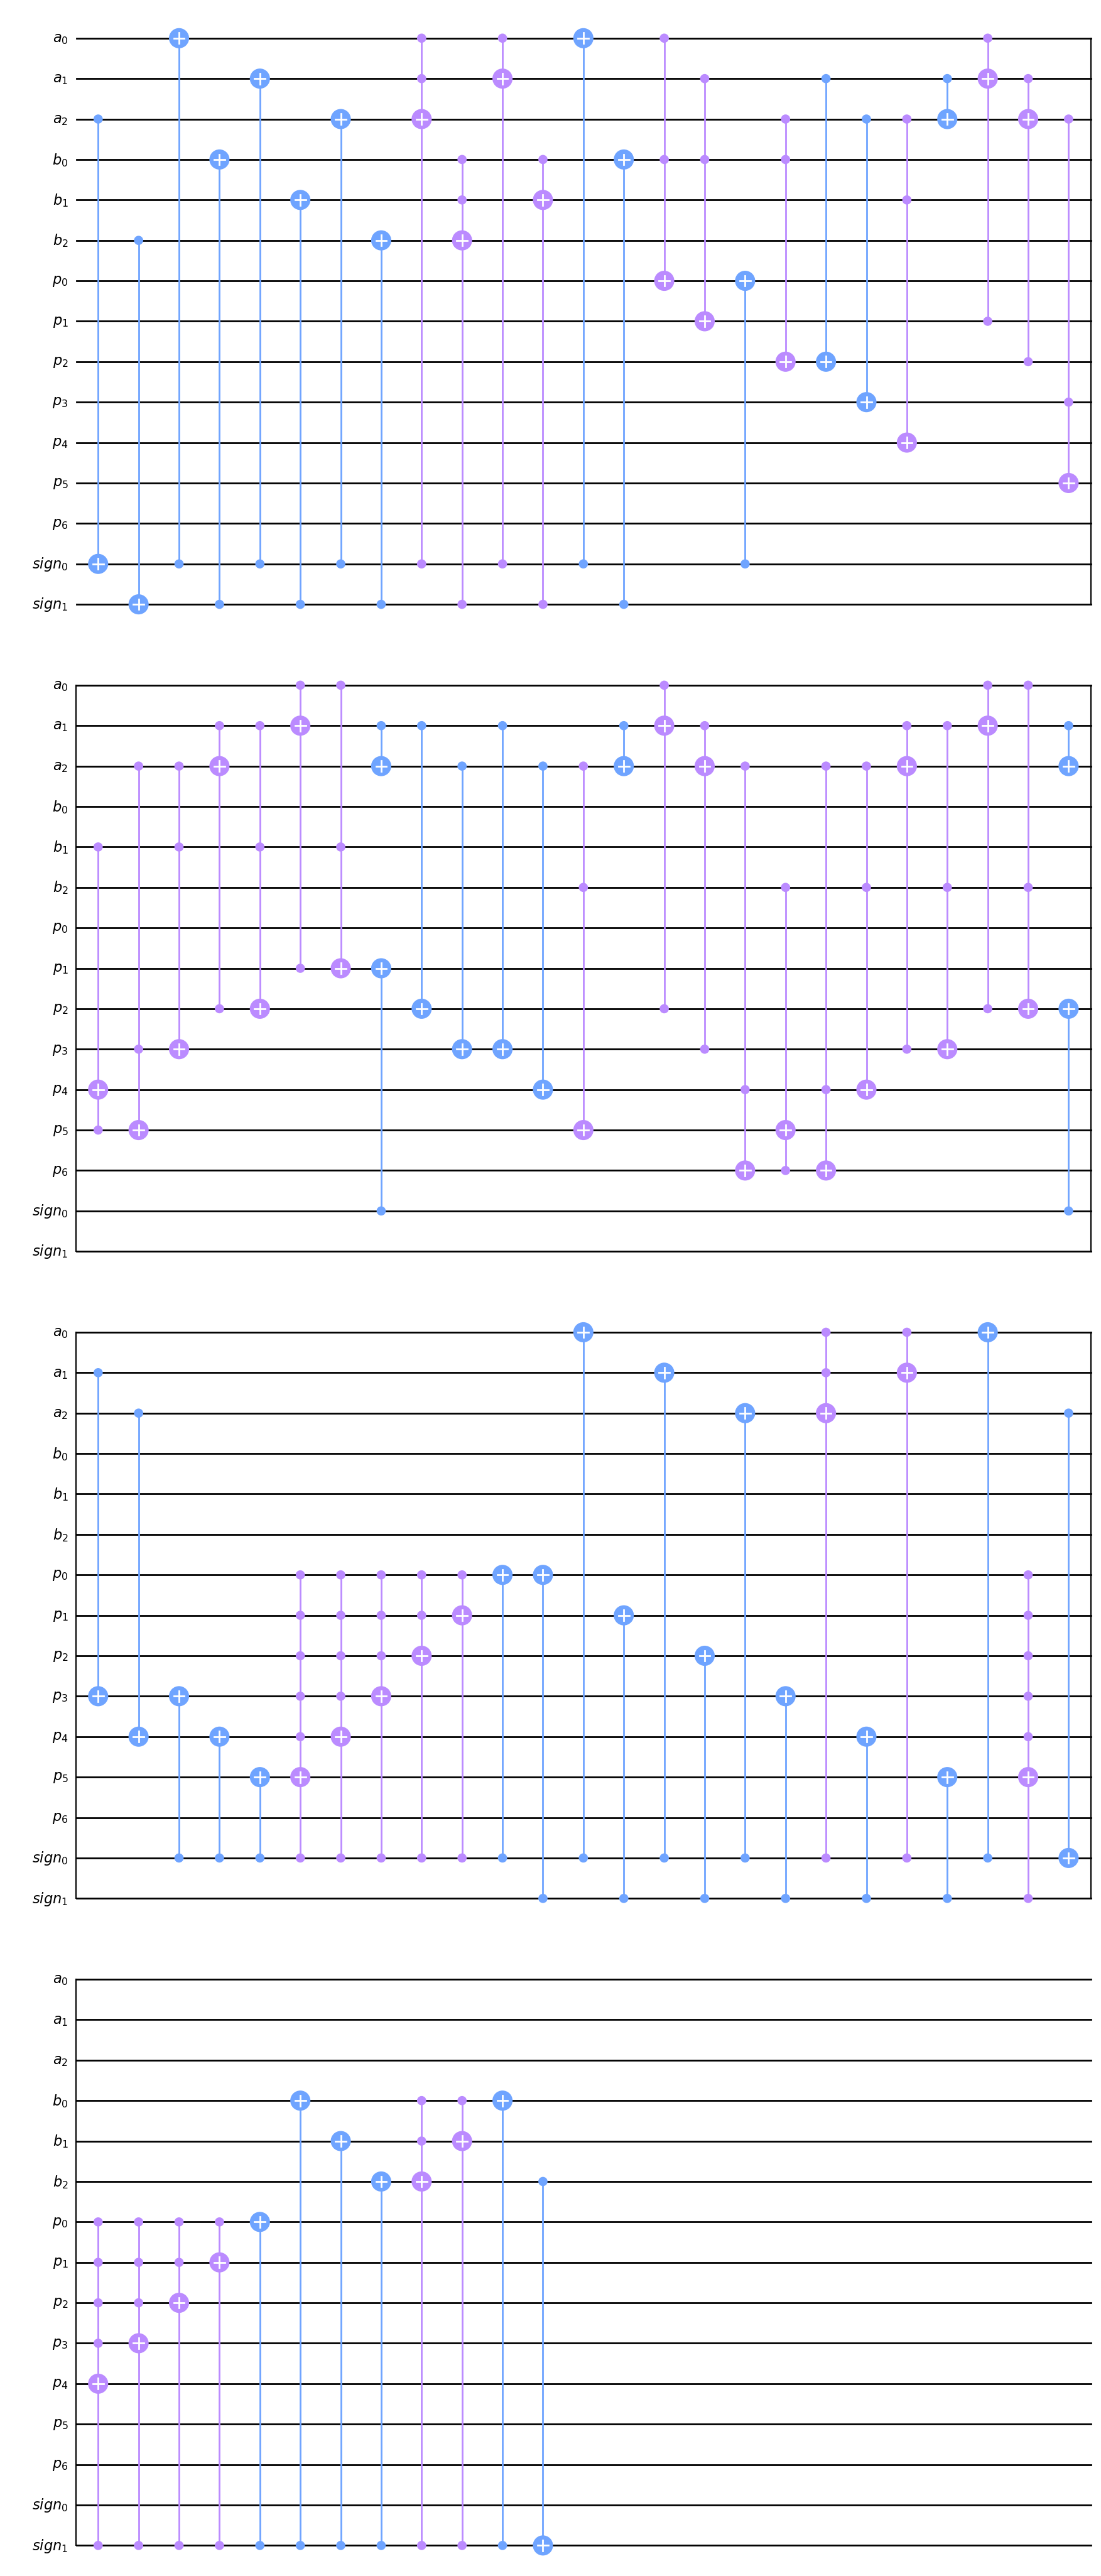

In [ ]:
n = 3
a = QuantumRegister(n, 'a')
b = QuantumRegister(n, 'b')
p = QuantumRegister(2*n + 1, 'p')
sign = QuantumRegister(2, 'sign')

qc = QuantumCircuit(a, b, p, sign)
basic_arithmetic_circuits.Twos_complement_integer_multiplication_gate(qc, a, b, p, sign, useElementaryGates=False)

# Exhaustively test all pairs of unsigned n-bit integers.
input_mask = 2**n - 1
product_mask = 2**(2*n) - 1
for b_val_std in range(int(2**n)):
    for a_val_std in range(int(2**n)):
        a_val = getTwosComplementInteger(a_val_std, n) # get the a_val for the same bit string in twos complement form
        b_val = getTwosComplementInteger(b_val_std, n)

        integer_input_std = a_val_std | (b_val_std << n)  # p starts in |0...0>
        input_state = Statevector.from_int(integer_input_std, dims=2**qc.num_qubits)
        output_state = input_state.evolve(qc)
        integer_output_std = int(np.argmax(np.abs(output_state.data)))

        output_a_std = integer_output_std & input_mask
        output_b_std = (integer_output_std >> n) & input_mask
        output_p_std = (integer_output_std >> (2*n)) & product_mask
        output_work = integer_output_std >> (4*n)

        output_a = getTwosComplementInteger(output_a_std, n) # get the a_val for the same bit string in twos complement form
        output_b = getTwosComplementInteger(output_b_std, n)
        output_p = getTwosComplementInteger(output_p_std, 2*n)

        assert output_a == a_val, f"a was not preserved for {a_val} * {b_val}"
        assert output_b == b_val, f"b was not preserved for {a_val} * {b_val}"
        assert output_p == a_val * b_val, (
            f"incorrect product for {a_val} * {b_val}: got {output_p}"
        )
        assert output_work == 0, f"work qubit was not cleared for {a_val} * {b_val}"

print(f"All {2**(2*n)} products for {n}-bit inputs passed.")
print(dict(qc.count_ops()))
qc.draw('mpl')
